In [1]:
from sklearn.datasets import fetch_california_housing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
house = fetch_california_housing()
X = house.data
y = house.target
df = pd.DataFrame(X,columns=house.feature_names)
df['target'] = y
# df.head()

df_shufled = df.sample(frac=1,random_state=123)

In [3]:
X = df_shufled.drop('target',axis=1).to_numpy()
y = df_shufled['target'].to_numpy()

In [4]:
def test_train_split(X,y,test_size=0.2):
  test_size = int(len(X) * test_size)
  return X[:test_size],X[test_size:],y[:test_size],y[test_size:]

In [5]:
X_test,X_train,y_test,y_train = test_train_split(X,y,0.2)
y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)

In [6]:
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)

In [7]:
X_train_scaled = (X_train - mu) / sigma
X_test_scaled  = (X_test  - mu) / sigma

In [8]:
X_train_scaled = np.hstack((np.ones((X_train_scaled.shape[0],1)), X_train_scaled))
X_test_scaled  = np.hstack((np.ones((X_test_scaled.shape[0],1)), X_test_scaled))

In [9]:
def mse(X,y,theta):
  m = len(y)
  y_pred = make_prediction(X,theta)
  error = (1/m) * np.sum((y_pred - y)**2)
  return error


In [10]:
def calc_gradient(X,y,theta):
  m = len(y)
  y_pred = make_prediction(X,theta)
  return (1/m) * X.T.dot(y_pred - y)


In [11]:
def make_prediction(X,theta):
  return X@theta


In [12]:
def train_LR_model(X,y,lr=0.005,epoch=1000):
  theta = np.zeros((X.shape[1],1))
  losses = []

  for _ in range(epoch):
    gradient = calc_gradient(X,y,theta)
    theta -= lr*gradient
    losses.append(mse(X,y,theta))
  return theta, losses



In [13]:
theta , losses = train_LR_model(X_train_scaled,y_train)

[]

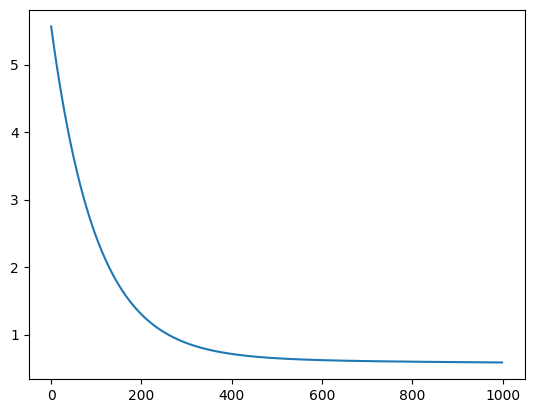

In [14]:
sns.lineplot(losses)
plt.plot()

In [15]:
y_pred = make_prediction(X_test_scaled,theta)

In [16]:
y_pred.shape

(4128, 1)

In [22]:
residuals = y_pred - y_test

<Axes: ylabel='Count'>

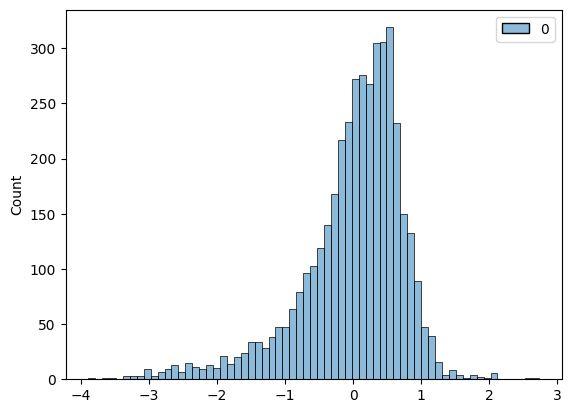

In [23]:
sns.histplot(residuals)

In [24]:
pd.DataFrame({"Actual Value":y_test.flatten(),"Prected Value":y_pred.flatten()})

,Actual Value,Prected Value
0,1.516,2.218850
1,0.992,1.678456
2,1.345,1.980573
3,2.317,1.456588
4,4.629,2.564446
...,...,...
4123,1.014,1.859629
4124,1.589,1.343940
4125,0.659,1.069291
4126,2.171,1.524584


In [20]:
1 - (np.sum((y_test.flatten() - y_pred.flatten())**2) / np.sum((y_test.flatten() - (y_test.flatten()).mean())**2))

np.float64(0.5613408963378148)

In [25]:
mse(X_test_scaled,y_test,theta)

np.float64(0.5833350825379627)

In [26]:
mse(X_train_scaled,y_train,theta)

np.float64(0.5876154154371759)

In [27]:
np.mean((y_test - y_test.mean())**2)

np.float64(1.3298141487727875)